<!--
Copyright 2026 EUMETSAT

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
-->

# Sentinel-3 SLSTR Level 2 Fire Radiative Power

The [Sentinel-3 SLSTR Level 2 Fire Radiative Power product](https://user.eumetsat.int/resources/user-guides/copernicus-sentinel-3-slstr-near-real-time-fire-radiative-power) reports thermal anomalies observed by the Sea and Land Surface Temperature Radiometer (SLSTR) on Sentinel-3A and Sentinel-3B. Fire radiative power (FRP), measured in megawatts, describes the rate of radiant energy released.

Use its standard mid-wave infrared (MWIR) detection tables to explore **Spain in July 2026**. Download the observations, write a Parquet dataset with Firecube, then compare days and inspect detections on a map. Thermal anomalies can also come from sources such as gas flares; each point is a satellite detection, not a confirmed individual wildfire.

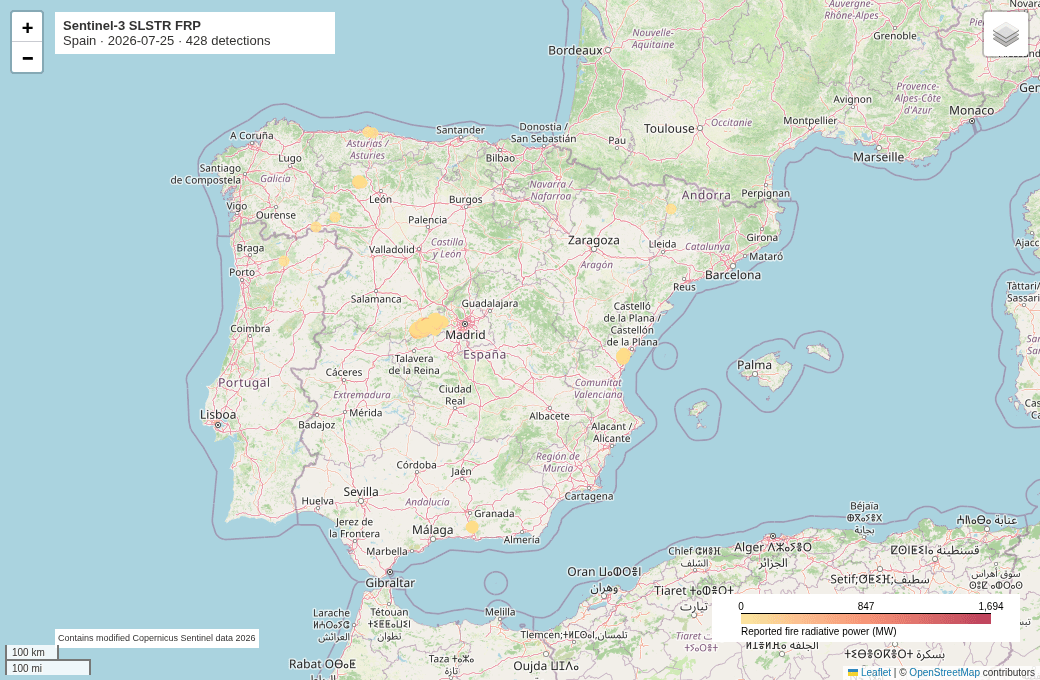

Use the map to zoom into an area and click a detection to see its observation time and reported fire radiative power. Create the plugin from the cells below, then run it with the Firecube CLI. The generated project stays in your working folder so you can edit and run it outside Jupyter.

## Before You Start

<div class="alert alert-block alert-warning">
<p>Use <strong>Python 3.12</strong> in local JupyterLab or upload this notebook to your JupyterHub and select a Python 3.12 kernel. To launch JupyterLab locally: <code>uv tool run --from jupyterlab jupyter lab</code>.</p>
<p>Data access requires an <a href="https://user.eumetsat.int/">EUMETSAT account</a> and a consumer key and secret from the <a href="https://api.eumetsat.int/api-key">API key page</a>. The download uses only the detection tables, rather than whole product archives. The basemap also needs an internet connection.</p>
<p>Run the cells in order with <strong>Shift+Enter</strong>. If Jupyter asks for a kernel restart after installation, restart and continue with the imports.</p>
</div>

In [ ]:
%pip install -q firecube==0.1.6 eumdac==3.1.1 pandas==3.0.5 matplotlib==3.11.2 folium==0.20.0 uv==0.12.13

## Choose The Area And Month

[EUMDAC](https://user.eumetsat.int/resources/user-guides/eumetsat-data-access-client-eumdac-guide) searches the EUMETSAT Data Store by date and bounding box. The bounds below cover mainland Spain and the Balearic Islands, with parts of neighbouring countries. They are a rectangle, not a national boundary.

The search finds products whose coverage intersects this rectangle. Later, pandas selects the individual detections inside it.

In [1]:
import hashlib
import json
import os
import shutil
import sys
from getpass import getpass
from pathlib import Path
from tempfile import mkdtemp

import eumdac
import folium
import matplotlib.pyplot as plt
import pandas as pd
from branca.colormap import LinearColormap
from IPython.display import display

# Use the CLI installed in this notebook's Python environment.
os.environ["PATH"] = str(Path(sys.executable).parent) + os.pathsep + os.environ["PATH"]
os.environ["FIRECUBE_LOG_FORMAT"] = "plain"
os.environ["FIRECUBE_LOG_LEVEL"] = "WARNING"
os.environ["UV_NO_PROGRESS"] = "1"
os.environ["NO_COLOR"] = "1"

WEST, SOUTH, EAST, NORTH = -9.5, 35.5, 4.5, 44.5
START = "2026-07-01"
END = "2026-08-01"  # exclusive end of the analysis period
COLLECTION = "EO:EUM:DAT:0417"
query = {
    "dtstart": START + "T00:00:00Z",
    "dtend": END + "T00:00:00Z",
    "bbox": f"{WEST},{SOUTH},{EAST},{NORTH}",
}
input_directory = Path("inputs") / f"spain-{START}"
input_directory.mkdir(parents=True, exist_ok=True)
manifest_path = input_directory / "manifest.json"

## Download The Detection Tables

Use the standard MWIR detections from [Sentinel-3 SLSTR FRP](https://user.eumetsat.int/catalogue/EO%3AEUM%3ADAT%3A0417). The cell asks for your credentials through masked prompts and downloads one CSV table per matching product. Keep credentials out of saved cells.

A manifest records the selected products and checksums. A rerun reuses completed downloads for the same query. If you change the bounds, it makes a new selection.

In [2]:
def get_observations():
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text())
        if manifest["query"] == query and all(
            (input_directory / item["filename"]).exists() for item in manifest["products"]
        ):
            print(f"Reusing {len(manifest['products'])} downloaded tables.")
            return manifest

    credentials = (getpass("EUMETSAT consumer key: "), getpass("EUMETSAT consumer secret: "))
    token = eumdac.AccessToken(credentials, cache=False)
    del credentials
    store = eumdac.DataStore(token)
    results = store.get_collection(COLLECTION).search(**query)
    print(f"Found {len(results)} products. Downloading their standard MWIR tables...")
    products = []
    for index, product in enumerate(results, start=1):
        product_id = str(product)
        entry = f"{product_id}/FRP_MWIR1km_standard.csv"
        destination = input_directory / f"{product_id}.csv"
        if not destination.exists():
            partial = destination.with_suffix(".csv.part")
            try:
                with product.open(entry=entry) as source, partial.open("wb") as target:
                    shutil.copyfileobj(source, target)
                partial.replace(destination)
            finally:
                partial.unlink(missing_ok=True)
        products.append(
            {
                "product": product_id,
                "entry": entry,
                "filename": destination.name,
                "sha256": hashlib.sha256(destination.read_bytes()).hexdigest(),
                "bytes": destination.stat().st_size,
            }
        )
        if index % 25 == 0:
            print(f"{index} tables ready")
    if not products:
        raise ValueError("No products found. Check the dates and bounding box.")
    manifest = {"collection": COLLECTION, "query": query, "products": products}
    manifest_path.write_text(json.dumps(manifest, indent=2))
    print(f"Ready: {len(products)} tables, {sum(p['bytes'] for p in products) / 1e6:.1f} MB.")
    return manifest


manifest = get_observations()
source_files = [input_directory / item["filename"] for item in manifest["products"]]
for item, path in zip(manifest["products"], source_files, strict=True):
    assert hashlib.sha256(path.read_bytes()).hexdigest() == item["sha256"]

Reusing 322 downloaded tables.


## Create The Plugin

`firecube plugins create` generates a Python project with a Parquet reader template. The `!` prefix runs a shell command in Jupyter; omit it when using a terminal.

Keep the project under `plugins/`. On a rerun, reuse it instead of scaffolding it again.

In [3]:
plugin_directory = Path("plugins/firecube-sentinel3-frp")
if not plugin_directory.exists():
    !firecube plugins create sentinel3-frp \
        --template parquet \
        --target-dir plugins \
        --license Apache-2.0 \
        --non-interactive

print("Plugin source:", plugin_directory / "src/firecube_sentinel3_frp/ingestor.py")

Plugin source: plugins/firecube-sentinel3-frp/src/firecube_sentinel3_frp/ingestor.py


## Implement The Reader

`%%writefile` replaces the generated `ingestor.py` with the code in this cell. The plugin reads the selected files from the download manifest, combines UTC day and time into `timestamp`, and keeps the source product identifier. Firecube batches the files and writes the returned tables to Parquet.

In [4]:
%%writefile plugins/firecube-sentinel3-frp/src/firecube_sentinel3_frp/ingestor.py
# Copyright 2026 EUMETSAT
# SPDX-License-Identifier: Apache-2.0

import json
from pathlib import Path
from typing import ClassVar

import pandas as pd

from firecube.ingestor.api import (
    GenericParquetIngestor,
    PipelineBatch,
    PluginContext,
    register_ingestor,
)


@register_ingestor("sentinel3_frp")
class Sentinel3FrpIngestor(GenericParquetIngestor):
    PRODUCT_NAME: ClassVar[str] = "sentinel3_frp"

    def discover_source_files(self, ctx: PluginContext):
        directory = Path(ctx.source)
        manifest = json.loads((directory / "manifest.json").read_text())
        return [directory / item["filename"] for item in manifest["products"]]

    def build_dataset(
        self, group: str, batch: PipelineBatch, ctx: PluginContext
    ) -> pd.DataFrame | None:
        frames = []
        for item in batch.items:
            frame = pd.read_csv(
                ctx.materialize(item),
                comment="#",
                usecols=["day", "time", "lat(deg)", "lon(deg)", "FRP(MW)"],
                dtype={"lat(deg)": float, "lon(deg)": float, "FRP(MW)": float},
            )
            if frame.empty:
                continue
            frame["timestamp"] = pd.to_datetime(
                frame["day"].astype(str) + "T" + frame["time"].astype(str), utc=True
            )
            frame = frame.drop(columns=["day", "time"])
            frame["source_product"] = Path(str(item)).name.removesuffix(".csv")
            frames.append(frame)
        return pd.concat(frames, ignore_index=True) if frames else None

Overwriting plugins/firecube-sentinel3-frp/src/firecube_sentinel3_frp/ingestor.py


## Install The Plugin

Declare pandas as a plugin dependency, then install the project in editable mode. Future edits to `ingestor.py` are picked up by the next CLI run.

In [5]:
project_file = plugin_directory / "pyproject.toml"
project_text = project_file.read_text()
if '\n    "pandas",' not in project_text:
    project_file.write_text(
        project_text.replace("dependencies = [", 'dependencies = [\n    "pandas",')
    )

!firecube plugins install --editable plugins/firecube-sentinel3-frp
!firecube plugins describe sentinel3_frp

Installing into environment: /path/to/notebook/environment/bin/python
Running: uv pip install -e plugins/firecube-sentinel3-frp --python /path/to/notebook/environment/bin/python


Using Python 3.12.12 environment at: environment
Resolved 60 packages in 41ms
   Building firecube-sentinel3-frp @ file:///path/to/notebook/plugins/firecube-sentinel3-frp


      Built firecube-sentinel3-frp @ file:///path/to/notebook/plugins/firecube-sentinel3-frp
Prepared 1 package in 254ms
Uninstalled 1 package in 0.23ms


Installed 1 package in 0.42ms
 ~ firecube-sentinel3-frp==0.1.0 (from file:///path/to/notebook/plugins/firecube-sentinel3-frp)
Installed 'plugins/firecube-sentinel3-frp' (editable)

Verifying installed plugins...


Detected plugins: sentinel3_frp


Name:        sentinel3_frp
Version:     0.1.0 (firecube-sentinel3-frp)
Module:      firecube_sentinel3_frp.ingestor
Product:     sentinel3_frp

Options Sections:
  [ENGINE]
      pipeline_workers [integer] (default: 1)
      pipeline_batch_size [integer] (default: 10)
      extract_workers [integer] (default: 4)
      cleanup_workspace [boolean] (default: False)
      workspace [str | None] (default: None)
      input_filters [list[str] | None] (default: None)
      write_mode [string] (default: staged)
      resume_existing [boolean] (default: False)
      force_reingest [boolean] (default: False)
      incremental [boolean] (default: False)
      dry_run [boolean] (default: False)
      duckdb_persist_batches [boolean] (default: False)
      upload_workers [integer] (default: 4)
      no_progress [boolean] (default: False)
      allow_empty_source [boolean] (default: False)
      validate_zarr [boolean] (default: False)
      validate_zarr_group [string] (default: )
      validate_za

## Ingest The Observations

Run the installed plugin against the downloaded tables. Each run writes to a fresh output directory, preserving earlier results. `--write-mode direct` writes straight to the local Parquet destination. The CLI summary is saved in `run-summary.json`; warnings and errors still appear below the command.

In [6]:
Path("outputs").mkdir(exist_ok=True)
run_directory = Path(mkdtemp(prefix="spain-fires-", dir="outputs")).resolve()
output_path = run_directory / "detections.parquet"
product_uri = output_path.as_uri()
summary_path = run_directory / "run-summary.json"
source_directory = str(input_directory.resolve())

!firecube ingest sentinel3_frp \
    --input-data "{source_directory}" \
    --target "{product_uri}" \
    --product-name sentinel3_frp \
    --output-format parquet \
    --write-mode direct \
    --option pipeline_workers=1 \
    --option pipeline_batch_size=25 \
    --option no_progress=true \
    > "{summary_path}"

print("Parquet output:", output_path.relative_to(Path.cwd()))

Parquet output: outputs/spain-fires-<run>/detections.parquet


<div class="alert alert-block alert-success">
<strong>Checkpoint.</strong> The detection tables are now a Parquet dataset.
</div>

## Compare Days In July

Read the Parquet dataset with pandas and keep detections inside the bounding box and July's UTC dates. The chart counts observations per day, including days with no detections.

Repeated observations can refer to the same fire, so these counts do not represent numbers of separate fires.


3,947 detections inside the bounding box during July 2026.


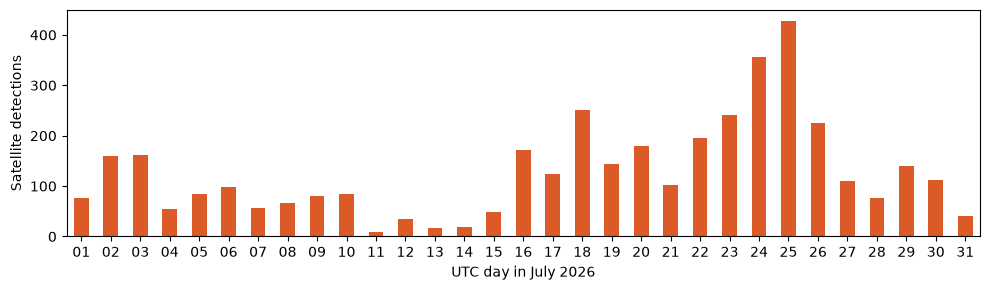

In [7]:
observations = pd.read_parquet(output_path).rename(
    columns={"lat(deg)": "latitude", "lon(deg)": "longitude", "FRP(MW)": "frp_mw"}
)
in_area = observations["longitude"].between(WEST, EAST) & observations["latitude"].between(
    SOUTH, NORTH
)
in_month = observations["timestamp"].ge(pd.Timestamp(START, tz="UTC")) & observations[
    "timestamp"
].lt(pd.Timestamp(END, tz="UTC"))
detections = (
    observations.loc[in_area & in_month].sort_values(["timestamp", "latitude", "longitude"]).copy()
)

if detections.empty:
    raise ValueError("No detections in this area and month. Check the selection.")
detections["day"] = detections["timestamp"].dt.strftime("%Y-%m-%d")
days = pd.date_range(START, END, inclusive="left").strftime("%Y-%m-%d")
daily_counts = detections.groupby("day").size().reindex(days, fill_value=0)
print(f"{len(detections):,} detections inside the bounding box during July 2026.")
ax = daily_counts.plot.bar(figsize=(10, 3), color="#dc5a27")
ax.set(xlabel="UTC day in July 2026", ylabel="Satellite detections")
ax.set_xticklabels([day[-2:] for day in days], rotation=0)
plt.tight_layout()
plt.show()

## Inspect A Day On The Map

Start with the day containing the most detections in this selection. Change `selected_day` to another July date, for example `"2026-07-15"`, and rerun this cell and the map cell.

A day with zero detections means no detections in these observations; it does not establish that there were no fires.

In [8]:
selected_day = daily_counts.idxmax()
selected = detections.loc[detections["day"] == selected_day]
print(f"{selected_day}: {len(selected):,} detections")

2026-07-25: 428 detections


[Folium](https://python-visualization.github.io/folium/latest/) places the observations on a labelled map. Zoom to a location and click a point for its UTC time and fire radiative power in megawatts. Use the layer control to show or hide the search rectangle.

Colour indicates reported radiative power. It does not show a burned-area boundary.

In [9]:
def map_detections(rows, day):
    view = folium.Map(
        location=[40.0, -3.5],
        zoom_start=6,
        tiles="OpenStreetMap",
        control_scale=True,
        prefer_canvas=True,
    )
    view.fit_bounds([[SOUTH, WEST], [NORTH, EAST]])
    area = folium.FeatureGroup(name="Search bounding box", show=False)
    folium.Rectangle([[SOUTH, WEST], [NORTH, EAST]], color="#526579", weight=2, fill=False).add_to(
        area
    )
    area.add_to(view)
    if rows.empty:
        print(f"No detections for {day}. Select another day above.")
    else:
        maximum = max(float(rows["frp_mw"].max()), 1.0)
        colours = LinearColormap(
            ["#fee08b", "#f46d43", "#a50026"],
            vmin=0,
            vmax=maximum,
            caption="Reported fire radiative power (MW)",
        )
        layer = folium.FeatureGroup(name=f"Detections · {day}")
        for row in rows.itertuples(index=False):
            folium.CircleMarker(
                location=[row.latitude, row.longitude],
                radius=5,
                color=colours(row.frp_mw),
                weight=1,
                fill=True,
                fill_color=colours(row.frp_mw),
                fill_opacity=0.8,
                tooltip=f"{row.frp_mw:.1f} MW · {row.timestamp:%H:%M} UTC",
                popup=(
                    f"<b>{row.timestamp:%Y-%m-%d %H:%M:%S} UTC</b><br>"
                    f"Fire radiative power: {row.frp_mw:.1f} MW<br>"
                    f"Location: {row.latitude:.4f}, {row.longitude:.4f}"
                ),
            ).add_to(layer)
        layer.add_to(view)
        colours.width = 300
        colours.add_to(view)
    folium.LayerControl(collapsed=True).add_to(view)
    view.get_root().html.add_child(
        folium.Element(
            '<div style="position:fixed;top:12px;left:55px;right:55px;max-width:280px;z-index:999;'
            'background:white;padding:6px 8px;font:13px sans-serif;">'
            f"<b>Sentinel-3 SLSTR FRP</b><br>Spain · {day} · {len(rows):,} detections</div>"
        )
    )
    view.get_root().html.add_child(
        folium.Element(
            '<p style="position:fixed;bottom:22px;left:55px;z-index:999;'
            'background:white;padding:3px;font-size:9px;">'
            "Contains modified Copernicus Sentinel data 2026</p>"
        )
    )
    view.get_root().header.add_child(
        folium.Element(
            "<style>.legend.leaflet-control {position:fixed; bottom:38px; right:10px; "
            "background:white; pointer-events:none; padding:4px;}</style>"
        )
    )
    return view


fire_map = map_detections(selected, selected_day)
fire_map.save(run_directory / "spain-fire-map.html")
display(fire_map)

## Try Another Area Or Date

- Change `selected_day` and rerun the last two cells to compare July days without downloading again.
- Change the bbox or month in **Choose The Area And Month**, then rerun the remaining cells to build another selection.
- Open `spain-fire-map.html` in your output directory to share the selected day's map. Its basemap needs an internet connection.

## Troubleshooting

| What happened? | What to do |
|---|---|
| EUMDAC reports an access error | Check your consumer key, secret, and collection access in the Data Store. |
| A download is interrupted | Rerun the download cell; completed tables are reused. |
| The map is blank in Jupyter | Trust this notebook after reviewing its code, and check that your browser can reach the basemap and Leaflet services. |
| An import fails after installation | Restart the kernel and continue from the imports cell. |
| No detections appear on the map | Choose another day; the daily chart shows which dates have detections. |

## Next Steps

- [GenericParquetIngestor](https://eumetsat.github.io/firecube/latest/guides/plugins/generic-parquet/): adapt the reader to another source table.
- [Plugin Development](https://eumetsat.github.io/firecube/latest/guides/plugins/): extend the generated project with configuration and telemetry.

Source: **Copernicus Sentinel data 2026**, distributed by EUMETSAT. Visualizations contain modified Copernicus Sentinel data 2026; see the [Sentinel data legal notice](https://sentinels.copernicus.eu/documents/247904/690755/Sentinel_Data_Legal_Notice). Basemap attribution appears on the map. Notebook code: Copyright 2026 EUMETSAT, Apache-2.0.